In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge

In [3]:
df = pd.read_parquet("data/data_clean/data_complet.parquet")

In [ ]:
# renomme la colonne nb_lic
df_agg = df.copy()

df_agg = df_agg.rename(columns={
    'licences_annuelles': 'nb_licencies'
})


df_agg = (
    df_agg
    .groupby(['code_sport', 'annee'], as_index=False)
    .agg({
        'nb_licencies': 'sum'
    })
)

In [ ]:
#on rajoute une colonne (qui correspond aux dernier jo)
def jo_reference(annee):
    if annee <= 2020: ### !!!!!!!
        return 2016
    elif annee < 2024:
        return 2020
    else:
        return 2024

df_agg['jo_ref'] = df_agg['annee'].apply(jo_reference)

In [ ]:
#### pb dataset trop gros
# garder une seule ligne par sport
df_sport = df.drop_duplicates(subset=["code_sport"])[
    ["code_sport","sport",
     "2016_or","2016_argent","2016_bronze","total_medailles_2016",
     "2020_or","2020_argent","2020_bronze","total_medailles_2020",
     "2024_or","2024_argent","2024_bronze","total_medailles_2024"]
]

# construire df_med (sport x jo_ref) => petit 
df_med = pd.concat([
    df_sport[["code_sport","sport","2016_or","2016_argent","2016_bronze","total_medailles_2016"]]
        .rename(columns={"2016_or":"or","2016_argent":"argent","2016_bronze":"bronze","total_medailles_2016":"total_medailles"})
        .assign(jo_ref=2016),

    df_sport[["code_sport","sport","2020_or","2020_argent","2020_bronze","total_medailles_2020"]]
        .rename(columns={"2020_or":"or","2020_argent":"argent","2020_bronze":"bronze","total_medailles_2020":"total_medailles"})
        .assign(jo_ref=2020),

    df_sport[["code_sport","sport","2024_or","2024_argent","2024_bronze","total_medailles_2024"]]
        .rename(columns={"2024_or":"or","2024_argent":"argent","2024_bronze":"bronze","total_medailles_2024":"total_medailles"})
        .assign(jo_ref=2024),
], ignore_index=True)

print("df_sport shape:", df_sport.shape)
print("df_med shape:", df_med.shape)
df_med.head()


df_sport shape: (34, 14)
df_med shape: (102, 7)


,code_sport,sport,or,argent,bronze,total_medailles,jo_ref
0,ATH,Athlétisme,0.0,3.0,3.0,6.0,2016
1,AVI,Aviron,1.0,0.0,1.0,2.0,2016
2,BAD,Badminton,0.0,0.0,0.0,0.0,2016
3,BAK,Basket-ball,0.0,0.0,0.0,0.0,2016
4,BOX,Boxe,2.0,2.0,2.0,6.0,2016


In [ ]:
df_model = df_agg.merge(
    df_med[["code_sport", "jo_ref", "or", "argent", "bronze", "total_medailles"]],
    on=["code_sport", "jo_ref"],
    how="left"
)

# si un sport n'a pas de médailles : 0
for c in ["or", "argent", "bronze", "total_medailles"]:
    df_model[c] = df_model[c].fillna(0)

print("df_model shape:", df_model.shape)
df_model.head()

df_model shape: (306, 8)


,code_sport,annee,nb_licencies,jo_ref,or,argent,bronze,total_medailles
0,ATH,2016,301976,2016,0.0,3.0,3.0,6.0
1,ATH,2017,307018,2016,0.0,3.0,3.0,6.0
2,ATH,2018,314692,2016,0.0,3.0,3.0,6.0
3,ATH,2019,316749,2016,0.0,3.0,3.0,6.0
4,ATH,2020,305914,2016,0.0,3.0,3.0,6.0


In [ ]:
def safe_div(a, b): #très important sinon explosion et divergence
    return np.where(b == 0, 0.0, a / b)  # renvoie 0 si le deno = 0 (au lieu de NaN ou inf)

def build_lic_features(df_lic: pd.DataFrame) -> pd.DataFrame:
    df = df_lic.copy()  # secu données (copie = pas d'effet de bord)

    # vérification des col oblig (necessaire pour agg)
    required = ["code_sport", "annee", "licences_annuelles"]
    missing = [c for c in required if c not in df.columns]
    if missing: # si dataset cassé le code s'arrête proprement
        raise ValueError(f"Colonnes manquantes dans df: {missing}")

    # nettoyage des types (verif que ce sont les bons) et val manquante = 0 licences
    df["annee"] = df["annee"].astype(int)
    df["licences_annuelles"] = pd.to_numeric(df["licences_annuelles"], errors="coerce").fillna(0.0)

    # gere si colonne manquante ==> pipeline stable ne casse pas ==> s'adapte à plusieurs versions du dataset
    if "sexe" not in df.columns:
        df["sexe"] = "U"
    if "age" not in df.columns:
        df["age"] = np.nan
    if "grande_tranche_age" not in df.columns:
        df["grande_tranche_age"] = "Unknown"
    if "code_dep" not in df.columns:
        df["code_dep"] = "00"

    # crea flags sexe (~ onehot)
    df["is_femme"] = (df["sexe"] == "F").astype(int)
    df["is_homme"] = (df["sexe"] == "H").astype(int)

    # crea classe d'age (segment interpretables)
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["is_jeune_lt14"]  = ((df["age"] < 14) & df["age"].notna()).astype(int)
    df["is_jeune_14_17"] = ((df["age"] >= 14) & (df["age"] <= 17)).astype(int)
    df["is_adulte_18_34"] = ((df["age"] >= 18) & (df["age"] <= 34)).astype(int)
    df["is_adulte_35_49"] = ((df["age"] >= 35) & (df["age"] <= 49)).astype(int)
    df["is_senior_50p"]   = ((df["age"] >= 50)).astype(int)

    # pour chaque sport chaque année somme des lic indiv
    g = df.groupby(["code_sport", "annee"], as_index=False)

    base = g.agg(nb_licencies=("licences_annuelles", "sum"))

    # effectif reel
    sex = (
        df.groupby(["code_sport", "annee"])
          .apply(lambda x: pd.Series({
              "nb_femmes": (x["licences_annuelles"] * x["is_femme"]).sum(),
              "nb_hommes": (x["licences_annuelles"] * x["is_homme"]).sum(),
          }))
          .reset_index()
    )

    # moyenne d'age ponderee et dispersion (stat continue et coomptes dscrets)
    def _age_block(x):
        w = x["licences_annuelles"].to_numpy(dtype=float)
        a = x["age"].to_numpy(dtype=float)

        mask = ~np.isnan(a)
        w2 = w[mask]
        a2 = a[mask]

        if w2.sum() == 0:
            age_mean = np.nan
            age_std = np.nan
        else:
            age_mean = float((a2 * w2).sum() / w2.sum())
            age2_mean = float(((a2 ** 2) * w2).sum() / w2.sum())
            var = max(0.0, age2_mean - age_mean ** 2)
            age_std = float(np.sqrt(var))

        nb_lt14  = float(x.loc[x["is_jeune_lt14"] == 1, "licences_annuelles"].sum())
        nb_14_17 = float(x.loc[x["is_jeune_14_17"] == 1, "licences_annuelles"].sum())
        nb_18_34 = float(x.loc[x["is_adulte_18_34"] == 1, "licences_annuelles"].sum())
        nb_35_49 = float(x.loc[x["is_adulte_35_49"] == 1, "licences_annuelles"].sum())
        nb_50p   = float(x.loc[x["is_senior_50p"] == 1, "licences_annuelles"].sum())

        return pd.Series({
            "age_mean": age_mean,
            "age_std": age_std,
            "nb_lt14": nb_lt14,
            "nb_14_17": nb_14_17,
            "nb_18_34": nb_18_34,
            "nb_35_49": nb_35_49,
            "nb_50p": nb_50p,
        })

    age_stats = (
        df.groupby(["code_sport", "annee"])
          .apply(_age_block)
          .reset_index()
    )

    # au lieu de juste une col tranche d'age on "one hot"
    tranche = (
        df.groupby(["code_sport", "annee", "grande_tranche_age"], as_index=False)
          .agg(tranche_lic=("licences_annuelles", "sum"))
    )

    tranche_wide = (
        tranche.pivot_table(
            index=["code_sport", "annee"],
            columns="grande_tranche_age",
            values="tranche_lic",
            aggfunc="sum",
            fill_value=0.0
        )
        .reset_index()
    )

    tranche_cols = [c for c in tranche_wide.columns if c not in ["code_sport", "annee"]]
    tranche_wide = tranche_wide.rename(
        columns={c: f"tranche_{str(c).strip().lower().replace(' ', '_')}" for c in tranche_cols}
    )

    # A reprednre.... géographie (nb dep actifs) et indice herfindahl (proche 1 = sport concentré)
    dept_sum = (
        df.groupby(["code_sport", "annee", "code_dep"], as_index=False)
          .agg(dep_lic=("licences_annuelles", "sum"))
    )

    dept_feat = (
        dept_sum.groupby(["code_sport", "annee"])
        .apply(lambda x: pd.Series({
            "nb_departements_actifs": int((x["dep_lic"] > 0).sum()),
            "herfindahl_dep": float((safe_div(x["dep_lic"].values, x["dep_lic"].sum()) ** 2).sum()) if x["dep_lic"].sum() > 0 else 0.0
        }))
        .reset_index()
    )

    # fusion de tous les blocs
    out = (
        base.merge(sex, on=["code_sport", "annee"], how="left")
            .merge(age_stats, on=["code_sport", "annee"], how="left")
            .merge(tranche_wide, on=["code_sport", "annee"], how="left")
            .merge(dept_feat, on=["code_sport", "annee"], how="left")
    )

    # parts (ratio): importants car comarable entre sports
    out["part_femmes"] = safe_div(out["nb_femmes"], out["nb_licencies"])
    out["part_hommes"] = safe_div(out["nb_hommes"], out["nb_licencies"])

    out["part_lt14"]  = safe_div(out["nb_lt14"], out["nb_licencies"])
    out["part_14_17"] = safe_div(out["nb_14_17"], out["nb_licencies"])
    out["part_18_34"] = safe_div(out["nb_18_34"], out["nb_licencies"])
    out["part_35_49"] = safe_div(out["nb_35_49"], out["nb_licencies"])
    out["part_50p"]   = safe_div(out["nb_50p"], out["nb_licencies"])

    # lags + dynamiques (important pour voir l'inertie et les dynamique passées)
    out = out.sort_values(["code_sport", "annee"]).reset_index(drop=True)

    for lag in [1, 2]:
        out[f"nb_licencies_lag{lag}"] = out.groupby("code_sport")["nb_licencies"].shift(lag)
        out[f"part_femmes_lag{lag}"] = out.groupby("code_sport")["part_femmes"].shift(lag)
        out[f"age_mean_lag{lag}"] = out.groupby("code_sport")["age_mean"].shift(lag)

    out["croissance_lag1"] = safe_div(out["nb_licencies"] - out["nb_licencies_lag1"], out["nb_licencies_lag1"])
    out["croissance_lag2"] = safe_div(out["nb_licencies_lag1"] - out["nb_licencies_lag2"], out["nb_licencies_lag2"])
    
    #moy glissante (var de controle)
    out["nb_licencies_roll2"] = (
        out.groupby("code_sport")["nb_licencies"]
           .shift(1)
           .rolling(2)
           .mean()
           .reset_index(level=0, drop=True)
    )

    return out



In [ ]:
lic_feat = build_lic_features(df)
print("lic_feat shape:", lic_feat.shape)

df_model_full = df_model.merge(
    lic_feat.drop(columns=["nb_licencies"]),  # pour éviter doublon
    on=["code_sport", "annee"],
    how="left"
)

print("df_model_full shape:", df_model_full.shape)

lic_feat shape: (306, 35)
df_model_full shape: (306, 40)


# Modèle principal econo
objectif: expliquer la croissance annuelle des licencies après les JO
Δlog(1+lic) ~ médailles_lastJO + FE_sport (effets fixes sport) + FE_anne (effet fixe annee)

In [ ]:
# MODÈLE PRINCIPAL (econo) : croissance post-JO
# Δlog(1+lic) ~ médailles_lastJO + FE_sport + FE_annee  (SE cluster sport)


import statsmodels.formula.api as smf

# trie pour que diff(1) fasse bien annee t- annee t-1 et copie pour pas modif df_model_full
dfp = df_model_full.sort_values(["code_sport", "annee"]).copy()

# éviter le mot "or" !!!!! pose pb (peut etre le renomer dès le début car sinon a posé pb dans tous mes modèles)
if "or" in dfp.columns:
    dfp = dfp.rename(columns={"or": "gold"})

# log + croissance (stabilise variance et rend comparable les sport (limite les effet de niveaux))
dfp["log_lic"] = np.log1p(dfp["nb_licencies"]) # log(1+nb_lic)
dfp["dlog_lic"] = dfp.groupby("code_sport")["log_lic"].diff(1) #log(1+l_t) - log(1+ l_(t-1)) = approx d'une croissance (taux)
#rq: me fait perdre la 1e année de sport mais normal car croissance

## juste pour corriger  et ne pas mettre 2 fois un truc déjà calculé
dfp["med_last"] = dfp["total_medailles"]


# fenêtre d'analyse (supprime les lignes sans croissance et garde uniquement 2017-2024)
dfp = dfp[dfp["annee"].between(2017, 2024)].copy()
dfp = dfp.dropna(subset=["dlog_lic"]).copy()

# variables additionnelles optionnelles (on garde seulement celles qui existent)
opt_controls = [c for c in ["part_femmes", "age_mean", "nb_departements_actifs"] if c in dfp.columns]
rhs = "med_last"
if opt_controls:
    rhs += " + " + " + ".join(opt_controls)

# régression : FE sport + FE année, SE cluster sport
#C(sport)= effet fixe sport
# C(annee) = choc commun a tous les sport (covid, pol publiques, etc)
#cluster sport  = erreur robustes pour correlation intra-sport
#necessaire pour ne pas confondre effet médaille et popularité structurelle
formula_main = f"dlog_lic ~ {rhs} + C(code_sport) + C(annee)"
main_model = smf.ols(formula_main, data=dfp).fit(
    cov_type="cluster", cov_kwds={"groups": dfp["code_sport"]}
)

print(main_model.summary())

# dlog_lic = variation en log==> approx en % donc 100*beta ~% de croissance mais attention c'est une approximatuon valide si beta petit (c'est le cas ici)
if "med_last" in main_model.params.index:
    beta = float(main_model.params["med_last"])
    print(f"\nInterprétation: +1 médaille -> ~ {100*beta:.2f}% de croissance annuelle (approx) sur log(1+lic).")
# i.e. ce bloc mesure l'effet moyen des médailles toutes choses égales par ailleurs

                            OLS Regression Results                            
Dep. Variable:               dlog_lic   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     10.75
Date:              ven., 26 déc. 2025   Prob (F-statistic):           4.96e-08
Time:                        11:52:40   Log-Likelihood:                 248.11
No. Observations:                 272   AIC:                            -406.2
Df Residuals:                     227   BIC:                            -244.0
Df Model:                          44                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  0

C:\Users\mcmoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 11
  warnings.warn('covariance of constraints does not have full '


Ce modèle en panel vise à estimer l’effet moyen des performances olympiques sur la croissance du nombre de licenciés, en contrôlant pour les différences structurelles entre disciplines et les chocs communs aux différentes années.

Les résultats suggèrent qu’une médaille supplémentaire lors du dernier JO est associée à une augmentation moyenne d’environ 0,10 point de pourcentage de la croissance annuelle du nombre de licenciés, toutes choses égales par ailleurs.

Cet effet, bien que statistiquement détectable, reste quantitativement modeste, ce qui indique que les performances olympiques ne constituent qu’un déterminant secondaire de la dynamique des licenciés, dominée par des facteurs structurels et inertiels.

Le nombre total de médailles ne distingue pas la nature des médailles (or vs bronze) ni leur visibilité médiatique, ce qui peut atténuer l’effet mesuré.

In [ ]:
# a enleevr aussi au propre
assert (dfp["med_last"] == dfp["total_medailles"]).all()


In [ ]:
# simple verification en 2spi mais à enlever dans le propre
dfp[["gold","argent","bronze","total_medailles","med_last"]].head()


,gold,argent,bronze,total_medailles,med_last
1,0.0,3.0,3.0,6.0,12.0
2,0.0,3.0,3.0,6.0,12.0
3,0.0,3.0,3.0,6.0,12.0
4,0.0,3.0,3.0,6.0,12.0
5,0.0,1.0,0.0,1.0,2.0


In [ ]:
# MODÈLE SECONDAIRE (prédiction par sport) : niveau + FE sport + lag
# log(1+lic_t) ~ log(1+lic_{t-1}) + trend + médailles_lastJO + FE_sport
# + Fonction plot(code_sport) -> courbes observé vs prédit
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# trie dans l'ordre pour que les lags soient ok
dfs = df_model_full.sort_values(["code_sport", "annee"]).copy()

# prediction en log pour stabiliser l'echelle
dfs["log_lic"] = np.log1p(dfs["nb_licencies"])

# lag log (inertie = lag 1) creer log(1+lic_t-1)
dfs["log_lic_lag1"] = dfs.groupby("code_sport")["log_lic"].shift(1)

# trend (croissance global, tendance)
dfs["trend"] = dfs["annee"] - dfs["annee"].min()

# médailles last JO : on utilise nb_med_last_jo si dispo, sinon somme

dfs["med_last"] = dfs["total_medailles"]


# garder uniquement obs avec lag (i.e. drop les lignes sans lags)
dfs = dfs.dropna(subset=["log_lic_lag1"]).copy()

# split temporel (train: 2017-2020 et test 2022-2024)
train_df = dfs[(dfs["annee"] >= 2017) & (dfs["annee"] <= 2020)].copy()
test_df  = dfs[(dfs["annee"] >= 2022) & (dfs["annee"] <= 2024)].copy()

# features numériques 
features_num = ["log_lic_lag1", "trend", "med_last"]
features_num += [c for c in ["part_femmes", "age_mean", "nb_departements_actifs"] if c in dfs.columns]
features_num = [c for c in features_num if c in dfs.columns]

# one-hot sport (effets fixes) — pour éviter un blow-up mémoire : float32
X_train = pd.get_dummies(train_df[["code_sport"] + features_num], columns=["code_sport"], drop_first=True).astype("float32")
X_test  = pd.get_dummies(test_df[["code_sport"] + features_num],  columns=["code_sport"], drop_first=True).astype("float32")
X_test = X_test.reindex(columns=X_train.columns, fill_value=0).astype("float32")

y_train = train_df["log_lic"].astype("float32").values
y_test  = test_df["log_lic"].astype("float32").values

# fit Ridge (stable en prédiction)
sec_model = Ridge(alpha=1.0)
sec_model.fit(X_train, y_train)

# perf globale (log)
pred_log_test = sec_model.predict(X_test)
print("R² (log) :", r2_score(y_test, pred_log_test))
print("MAE (niveau) :", mean_absolute_error(np.expm1(y_test), np.expm1(pred_log_test)))

def plot_pred_sport(code_sport: str):
    """
    Argument unique: code_sport (ex 'HAN', 'ATH').
    Trace observé vs prédit sur les années de test (2022-2024) et renvoie le DF affiché.
    """
    d = test_df[test_df["code_sport"] == code_sport].sort_values("annee").copy()
    if d.empty:
        print(f"Aucune donnée test pour {code_sport}")
        return None

    Xd = pd.get_dummies(d[["code_sport"] + features_num], columns=["code_sport"], drop_first=True).astype("float32")
    Xd = Xd.reindex(columns=X_train.columns, fill_value=0).astype("float32")

    d["pred_log"] = sec_model.predict(Xd)
    d["pred_nb_licencies"] = np.expm1(d["pred_log"])

    plt.figure(figsize=(8,5))
    plt.plot(d["annee"], d["nb_licencies"], marker="o", linewidth=2, label="observé")
    plt.plot(d["annee"], d["pred_nb_licencies"], marker="o", linewidth=2, linestyle="--", label="prédit")

    if "jo_ref" in d.columns and d["jo_ref"].notna().any():
        jo_year = int(d["jo_ref"].iloc[0])
        plt.axvline(jo_year, linestyle="--", alpha=0.4)

    plt.title(f"{code_sport} — Nombre de licenciés observé vs prédit (test)")
    plt.xlabel("Année")
    plt.ylabel("Nb licenciés")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return d[["code_sport", "annee", "nb_licencies", "pred_nb_licencies"]]

# plot_pred_sport("HAN")
# plot_pred_sport("ATH")

R² (log) : 0.9837913513183594
MAE (niveau) : 75650.1875


Nous construisons un second modèle orienté prédiction afin de reproduire, sport par sport, la trajectoire du nombre de licenciés après les JO. Le modèle est une régression Ridge sur log(1+lic_t) incluant un terme d’inertie log(1+lict−1​) , une tendance temporelle, les médailles du dernier JO, et des effets fixes par sport (dummies). Ce modèle est conçu pour la simulation et la visualisation (courbes observé vs prédit), plutôt que pour l’identification causale stricte.

Les deux modèles intègrent des effets fixes par sport, afin de contrôler l’hétérogénéité structurelle entre disciplines. Dans le modèle économétrique, ces effets fixes sont introduits via la notation C(code_sport) de statsmodels, tandis que dans le modèle de prédiction ils sont implémentés explicitement sous forme de variables indicatrices (one-hot encoding). La différence entre les modèles ne réside donc pas dans la prise en compte des effets fixes, mais dans la variable expliquée et l’objectif : identification causale pour le premier, prédiction et simulation pour le second


In [ ]:
def plot_pred_sport(code_sport: str):
    """
    Trace observé vs prédit pour un sport donné (ex: 'HAN', 'ATH')
    sur les années de test (2022–2024)
    """
    d = test_df[test_df["code_sport"] == code_sport].sort_values("annee").copy()
    if d.empty:
        print(f"Aucune donnée test pour {code_sport}")
        return None

    # design matrix du sport
    Xd = pd.get_dummies(
        d[["code_sport"] + features_num],
        columns=["code_sport"],
        drop_first=True
    ).astype("float32")

    Xd = Xd.reindex(columns=X_train.columns, fill_value=0)

    # prédictions
    d["pred_log"] = sec_model.predict(Xd)
    d["pred_nb_licencies"] = np.expm1(d["pred_log"])

    # graphique
    plt.figure(figsize=(8, 5))
    plt.plot(d["annee"], d["nb_licencies"], marker="o", linewidth=2, label="observé")
    plt.plot(d["annee"], d["pred_nb_licencies"], marker="o", linestyle="--", linewidth=2, label="prédit")

    if "jo_ref" in d.columns:
        jo = int(d["jo_ref"].iloc[0])
        plt.axvline(jo, linestyle="--", alpha=0.4)
        plt.text(jo + 0.1, plt.ylim()[1]*0.95, f"JO {jo}", alpha=0.6)

    plt.title(f"{code_sport} — Nombre de licenciés observé vs prédit")
    plt.xlabel("Année")
    plt.ylabel("Nb licenciés")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return d[["code_sport", "annee", "nb_licencies", "pred_nb_licencies"]]

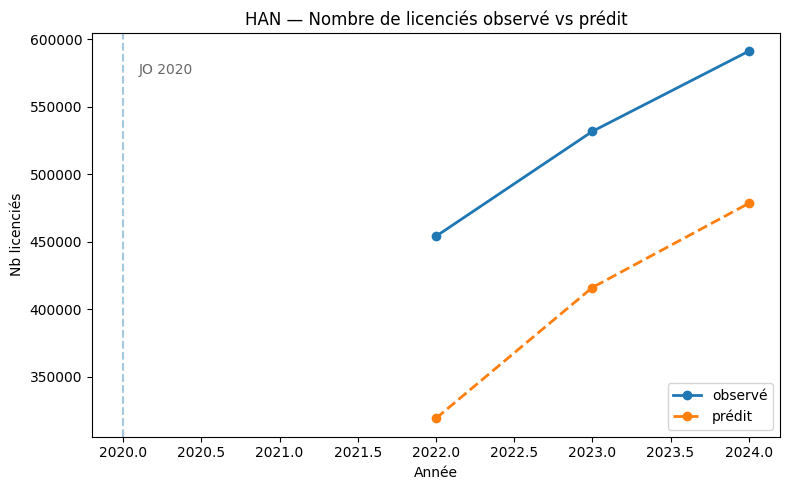

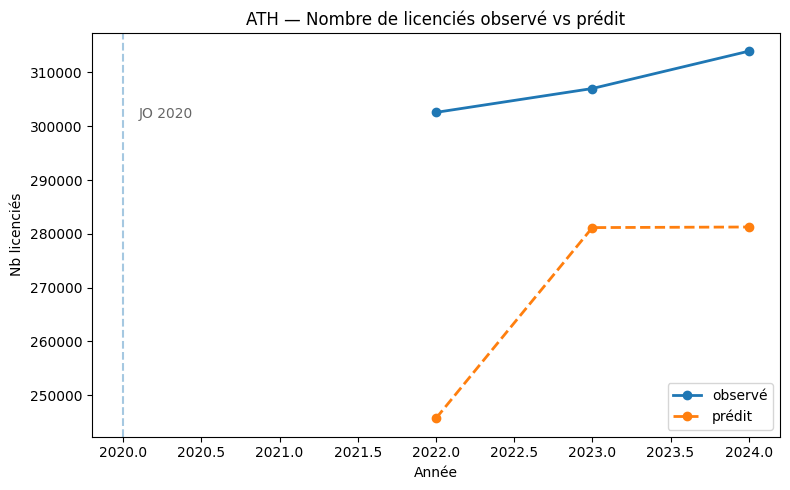

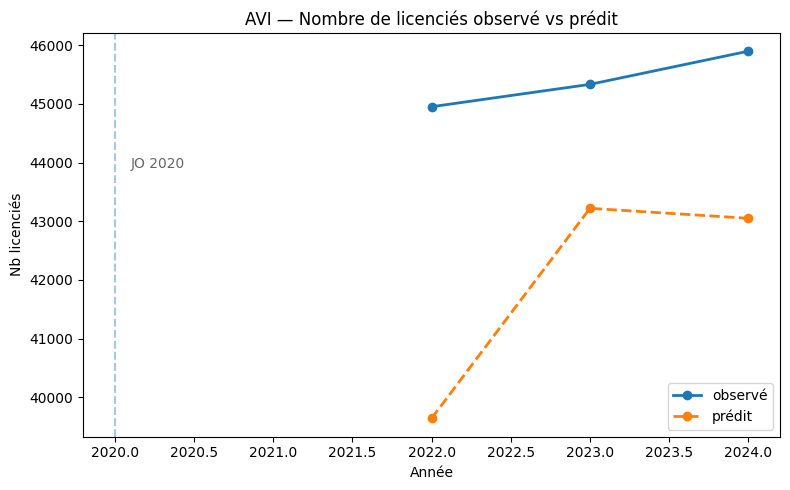

,code_sport,annee,nb_licencies,pred_nb_licencies
15,AVI,2022,44951,39642.479229
16,AVI,2023,45332,43220.361846
17,AVI,2024,45897,43050.526043


In [ ]:
plot_pred_sport("HAN")   
plot_pred_sport("ATH")  
plot_pred_sport("AVI")   

rq: la prediction catastrophique en 2022 est due à 2021 (on remarque d'autant plus que l'inertie joue puisqu'en 2021 il n'y avait pas licenciés recensés et que c'est ce qui est prédit pour 2022 et que pour 2023, le modèle se réadapte tout de suite avec la prédiction de 2022)

# preuve 1

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error

# =========================
# PREUVE INERTIE > JO : ablation
# suppose df_model_full existe déjà
# colonnes : code_sport, annee, nb_licencies, total_medailles, nb_licencies_lag1, etc.
# =========================

df_work = df_model_full.copy()

# cible en log (plus stable)
df_work["log_y"] = np.log1p(df_work["nb_licencies"])

# garder lignes avec lag1 dispo
df_work = df_work.dropna(subset=["nb_licencies_lag1"]).copy()
df_work["log_lag1"] = np.log1p(df_work["nb_licencies_lag1"])

# split temporel (comme toi)
train_df = df_work[(df_work["annee"] >= 2017) & (df_work["annee"] <= 2020)].copy()
test_df  = df_work[(df_work["annee"] >= 2022) & (df_work["annee"] <= 2024)].copy()

# fonctions utiles
def fit_eval(features, name):
    Xtr = pd.get_dummies(train_df[features], columns=["code_sport"], drop_first=True)
    Xte = pd.get_dummies(test_df[features], columns=["code_sport"], drop_first=True)
    Xte = Xte.reindex(columns=Xtr.columns, fill_value=0)

    ytr = train_df["log_y"].values
    yte = test_df["log_y"].values

    model = Ridge(alpha=1.0)
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(np.expm1(yte), np.expm1(pred))
    return {"model": name, "R2_log": r2, "MAE_niveau": mae}

# 3 modèles emboîtés
res = []
res.append(fit_eval(["code_sport", "log_lag1"], "M0: inertie seule (lag1)"))
#res.append(fit_eval(["code_sport", "total_medailles"], "M1: médailles seules"))
res.append(fit_eval(["code_sport", "log_lag1", "total_medailles"], "M2: inertie + médailles"))

pd.DataFrame(res)


,model,R2_log,MAE_niveau
0,M0: inertie seule (lag1),0.989764,49220.355231
1,M2: inertie + médailles,0.989673,49563.633972


# preuve 2

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

df_work = df_model_full.dropna(subset=["nb_licencies_lag1"]).copy()
df_work["log_y"] = np.log1p(df_work["nb_licencies"])
df_work["log_lag1"] = np.log1p(df_work["nb_licencies_lag1"])

train_df = df_work[(df_work["annee"] >= 2017) & (df_work["annee"] <= 2020)].copy()

features_num = ["log_lag1", "total_medailles"]
features_cat = ["code_sport"]

X = train_df[features_num + features_cat]
y = train_df["log_y"].values

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features_num),
        ("cat", "passthrough", features_cat),
    ],
    remainder="drop"
)

# dummies dans pipeline via get_dummies simple
X_dum = pd.get_dummies(X, columns=["code_sport"], drop_first=True)

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),  # safe car sparse possible
    ("ridge", Ridge(alpha=1.0))
])

pipe.fit(X_dum, y)

coef = pd.Series(pipe.named_steps["ridge"].coef_, index=X_dum.columns).sort_values(key=np.abs, ascending=False)
coef.head(15)


log_lag1           0.791780
code_sport_PEN    -0.352055
code_sport_DIV     0.335834
code_sport_FOO     0.235555
code_sport_BAS    -0.188186
code_sport_SUR    -0.185888
code_sport_HOC    -0.171833
code_sport_TEN     0.169549
code_sport_LUT    -0.151604
code_sport_HAL    -0.143528
code_sport_BOX    -0.140303
total_medailles    0.125222
code_sport_BAK     0.117264
code_sport_AVI    -0.115051
code_sport_ESC    -0.105762
dtype: float64

# preuve 3

In [ ]:
import statsmodels.formula.api as smf

dfw = df_model_full.dropna(subset=["nb_licencies_lag1"]).copy()
dfw["log_y"] = np.log1p(dfw["nb_licencies"])
dfw["log_lag1"] = np.log1p(dfw["nb_licencies_lag1"])

train_df = dfw[(dfw["annee"] >= 2017) & (dfw["annee"] <= 2020)].copy()

m0 = smf.ols("log_y ~ log_lag1 + C(code_sport)", data=train_df).fit()
m2 = smf.ols("log_y ~ log_lag1 + total_medailles + C(code_sport)", data=train_df).fit()

print("R2 m0:", m0.rsquared, " | R2 m2:", m2.rsquared)
print(m2.compare_f_test(m0))  # (F, p-value, df_diff)

R2 m0: 0.9991231621392457  | R2 m2: 0.9991231621392457
(-inf, nan, 0.0)


C:\Users\mcmoi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\regression\linear_model.py:2284: RuntimeWarning: divide by zero encountered in scalar divide
  f_value = (ssr_restr - ssr_full) / df_diff / ssr_full * df_full


Le MAE, exprimé en nombre de licenciés, reste élevé malgré un R² très élevé. Cela s’explique par l’ordre de grandeur de la variable expliquée et par le fait que le modèle est avant tout conçu pour capturer des dynamiques relatives plutôt que des niveaux absolus précis.